## Conditional Edges

Simple Weather Forecast Agent 🌦️

Let's use a simple scenario where an agent checks the weather forecast and then branches to a "Rainy Day" node or a "Sunny Day" node based on the prediction.

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END, START
from operator import add

# Define the state structure
class WeatherState(TypedDict):
    """Represents the state of our graph."""
    forecast: str  # Stores the weather forecast ('sunny' or 'rainy')
    response: str  # Stores the final response message

/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
import random

# The decision-making node (which will output the forecast)
def forecast_weather(state: WeatherState) -> WeatherState:
    """Predicts the weather and updates the state."""
    # Dummy prediction: 50% chance of rain
    prediction = "rainy" if random.random() < 0.5 else "sunny"
    print(f"-> Forecast: {prediction}")
    # Return a dictionary to update the state
    return {"forecast": prediction}

# Node for a sunny day
def sunny_day_node(state: WeatherState) -> WeatherState:
    """Generates a sunny day message."""
    message = "It's going to be sunny! Remember to wear sunscreen. ☀️"
    return {"response": message}

# Node for a rainy day
def rainy_day_node(state: WeatherState) -> WeatherState:
    """Generates a rainy day message."""
    message = "It's going to rain! Don't forget your umbrella. 🌧️"
    return {"response": message}

In [3]:
def route_weather(state: WeatherState) -> Literal["sunny", "rainy"]:
    """Determines the next node based on the 'forecast' in the state."""
    # This key must match a key in the mapping dictionary (see next step)
    return state["forecast"]

In [12]:
# Initialize the StateGraph
workflow = StateGraph(WeatherState)

# Add nodes
workflow.add_node("forecast", forecast_weather)
workflow.add_node("sunny", sunny_day_node)
workflow.add_node("rainy", rainy_day_node)

# Set the entry point (the first node to run)
workflow.set_entry_point("forecast")

# Add the conditional edge
# - Source node: "forecast" (where the decision is made)
# - Routing function: route_weather (the function that returns the next path key)
# - Mapping: The dictionary that maps the routing function's output to the next node

workflow.add_conditional_edges(
    "forecast",  # The source node
    route_weather,  # The routing function
    {
        "sunny": "sunny",  # If route_weather returns 'sunny', go to the 'sunny' node
        "rainy": "rainy"   # If route_weather returns 'rainy', go to the 'rainy' node
    }
)

# Connect the end nodes to the final graph stop
workflow.add_edge("sunny", END)
workflow.add_edge("rainy", END)

# Compile the graph
app = workflow.compile()

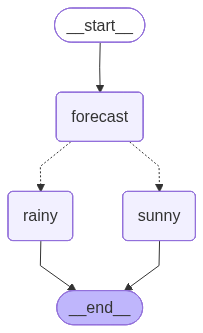

In [13]:
workflow.compile()

In [14]:
# Example 1: Run with an empty initial state (forecast_weather will populate it)
result_1 = app.invoke({})
print(f"Result 1 Response: {result_1['response']}")
# Output will be either the sunny or rainy message.



-> Forecast: rainy
Result 1 Response: It's going to rain! Don't forget your umbrella. 🌧️


In [15]:
# Example 2: Run again to show dynamic branching
result_2 = app.invoke({})
print(f"Result 2 Response: {result_2['response']}")
# Output will likely be different from Result 1.

-> Forecast: sunny
Result 2 Response: It's going to be sunny! Remember to wear sunscreen. ☀️
